# TinyChirp CNN build pipeline\n
\n
Trains one CNN on log-mel spectrograms, exports an int8 TFLite model, and writes a Rust audio sample file.

In [1]:
from typing import TYPE_CHECKING
from utils import (
    TARGET_FRAMES_MEL,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
)

if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "cnn_mel_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs
BATCH_SIZE = 32



In [2]:
from utils import (
    make_mel_datasets,
    NUM_MEL_BINS_MEL,
)

train_ds, val_ds, test_ds, label_names = make_mel_datasets(
    num_mel_bins=NUM_MEL_BINS_MEL,
    target_frames=TARGET_FRAMES_MEL,
)
num_labels = len(label_names)
print("Classes:", label_names)



Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.
Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']


In [ ]:
from utils import NUM_MEL_BINS_MEL, TARGET_FRAMES_MEL, init_wandb, get_callbacks, finish_wandb

CONV_FILTER_SIZE = 3
N_CHANNELS = 4

TARGET_FRAMES = TARGET_FRAMES_MEL
NUM_MEL_BINS = NUM_MEL_BINS_MEL

end_of_conv1_s1 = (TARGET_FRAMES - CONV_FILTER_SIZE + 1) // 2
end_of_conv2_s1 = (end_of_conv1_s1 - CONV_FILTER_SIZE + 1) // 2
end_of_conv1_s2 = (NUM_MEL_BINS - CONV_FILTER_SIZE + 1) // 2
end_of_conv2_s2 = (end_of_conv1_s2 - CONV_FILTER_SIZE + 1) // 2

model = keras.Sequential([
    keras.layers.Input(shape=(TARGET_FRAMES, NUM_MEL_BINS, 1)),
    keras.layers.Conv2D(N_CHANNELS, (CONV_FILTER_SIZE, CONV_FILTER_SIZE), activation="relu"),
    keras.layers.AveragePooling2D((2, 2)),
    keras.layers.Conv2D(N_CHANNELS, (CONV_FILTER_SIZE, CONV_FILTER_SIZE), activation="relu"),
    keras.layers.AveragePooling2D((2, 2)),
    keras.layers.Reshape((end_of_conv2_s2 * end_of_conv2_s1 * N_CHANNELS,)),
    keras.layers.Dense(8, activation="relu"),
    keras.layers.Dense(num_labels),
])
model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)


init_wandb(MODEL_STEM, config={
    "conv_filter_size": CONV_FILTER_SIZE,
    "n_channels": N_CHANNELS,
})

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776436902.919483   31347 service.cc:145] XLA service 0x7d92f80275d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776436902.919531   31347 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9


 17/353 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5580 - loss: 0.9555

I0000 00:00:1776436904.842644   31347 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9170 - loss: 0.2155 - val_accuracy: 0.9696 - val_loss: 0.0989
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9648 - loss: 0.0956 - val_accuracy: 0.9761 - val_loss: 0.0835
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.9736 - loss: 0.0705 - val_accuracy: 0.9775 - val_loss: 0.0676
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.9843 - loss: 0.0429 - val_accuracy: 0.9841 - val_loss: 0.0572
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.9876 - loss: 0.0337 - val_accuracy: 0.9819 - val_loss: 0.0635
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9924 - loss: 0.0246 - val_accuracy: 0.9870 - val_loss: 0.0531
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9934 - loss: 0.0175 - val_accuracy: 0.9899 - val_loss: 0.0490
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.9956 - loss: 0.0135 - val_

batch/accuracy,▁▆▆▆▇▇▇▇████████████████████████████████
batch/batch_step,▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▅▆▇▇▇███████████
epoch/epoch,▁▁▂▂▃▃▄▄▅▅▅▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▆▅▆▇▆██▇▇█████
epoch/val_loss,█▆▄▂▃▂▁▄▂▂▆▄▄▄▆▃▄
+6,...


In [4]:
from utils import (
    build_representative_batches,
    export_keras_model_to_int8_tflite,
)

val_specs = build_representative_batches(test_ds, take=100)

try:
    export_keras_model_to_int8_tflite(model, val_specs, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"Conversion failed: {e}")

Saved artifact at '/tmp/tmpfffvlfpc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 184, 80, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  138074825931440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138074398306752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138074398305872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138074398307632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138074398306576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138074398307104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138074398307456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138074398307984: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1776437290.899579   31198 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776437290.899955   31198 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/cnn_mel_tf.tflite


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Model size : 25.1 KB
Est. MFLOPs: 0.349
=== Binary classifier metrics : TEST SET===
Threshold: 0.5904  (best F2 threshold)
Accuracy : 0.9777
Precision: 0.9402
Recall   : 0.9956
F2 score : 0.9840
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9999


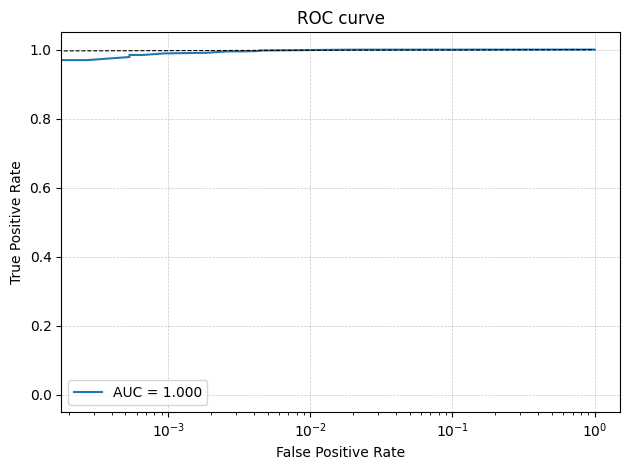

Avg inference: 0.981 ms


In [5]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, MODEL_STEM, train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")